# House Price Prediction

### PROBLEM STATEMENT

Accurately predicting house prices is a critical task for buyers, sellers, and real
estate professionals. This project uses the Ames Housing dataset to build a
regression model that predicts a house's sale price based on its physical
characteristics, quality ratings, and location.

The goal is to compare multiple regression models, engineer meaningful features
from the raw data, and tune the best-performing model to produce accurate,
interpretable price predictions.


In [8]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost

  Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

import joblib

## 1. Load the Data

In [3]:
home = pd.read_csv('train.csv')
home.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
home.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

The code above shows the basic information about the data set like number of columns, data type of columns and nuber of rows.

In [5]:
home.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The code above shows the statistical information about the data set 

In [ ]:
home.dtypes


Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [6]:
home.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 2. Data Cleaning

Handling missing values by displaying columns with missing values, along side the amount of missing values they have and filling them with the median of the entire row, none in case of missing categorical values, mode of the entire columns and 0s where necessary

Displaying missing values for columns containing missing values

In [7]:
missing = home.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Filling missing values with the median of the entire column, none in case of missing categorical values, mode of the entire columns and 0s where necessary

In [17]:
none_fill_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                   'GarageQual', 'GarageFinish', 'GarageType', 'GarageCond',
                   'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType1',
                   'MasVnrType']
for col in none_fill_cols:
    home[col] = home[col].fillna('None')

home['GarageYrBlt'] = home['GarageYrBlt'].fillna(0)
home['MasVnrArea'] = home['MasVnrArea'].fillna(0)
home['LotFrontage'] = home['LotFrontage'].fillna(home['LotFrontage'].median())
home['Electrical'] = home['Electrical'].fillna(home['Electrical'].mode()[0])

print(home.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


## 3. Outlier Removal (IQR method)

Applied to the key numerical columns to reduce the influence of extreme values
before feature engineering.

Text(0.5, 1.0, 'Boxplot of saleprice before outlier removal')

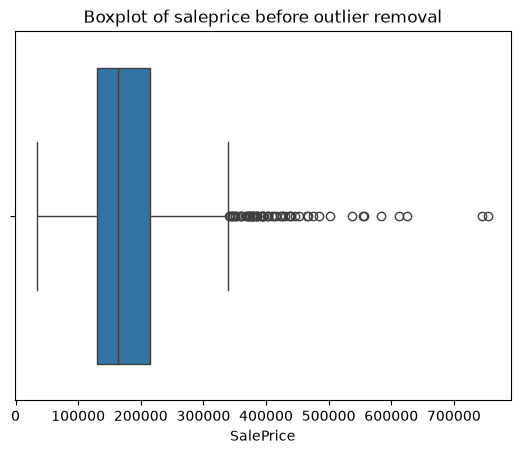

In [30]:
sns.boxplot(x = home['SalePrice'])
plt.title('Boxplot of saleprice before outlier removal')

The boxplot above shows that there are outliers present in the saleprice column

IQR mehod was used for detecting ouliers e.g rows whose values were below 0.25 quantile and higher than 0.75 quantile

In [25]:
def detect_outliers(df, columns):
    outlier_counts = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        print(f'{col}: {outliers.shape[0]}')
        outlier_counts[col] = outliers.shape[0]
    return outlier_counts

In [27]:
numeric_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'SalePrice']
detect_outliers(home,numeric_cols)

GrLivArea: 31
LotArea: 69
TotalBsmtSF: 61
SalePrice: 61


{'GrLivArea': 31, 'LotArea': 69, 'TotalBsmtSF': 61, 'SalePrice': 61}

The function detected 61 outliers in Grliv area, 69 in lot area, 61 in TotalBsmtsf and 61 in sale price. 

In [36]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lowerbound = Q1 - 1.5 * IQR
        upperbound = Q3 + 1.5 * IQR

        before = df.shape[0]
        df = df[(df[col] >= lowerbound) & (df[col] <= upperbound)]
        after = df.shape[0]

        print(f'{col}: removed {before - after} outliers')
    return df

home = remove_outliers(home, numeric_cols)
     


GrLivArea: removed 31 outliers
LotArea: removed 72 outliers
TotalBsmtSF: removed 60 outliers
SalePrice: removed 51 outliers


The function was able to remove 31 outliers in Grlivarea , 72 in lot area, 60 in TotalBsmtsf and 51 in Saleprice

<Axes: xlabel='SalePrice'>

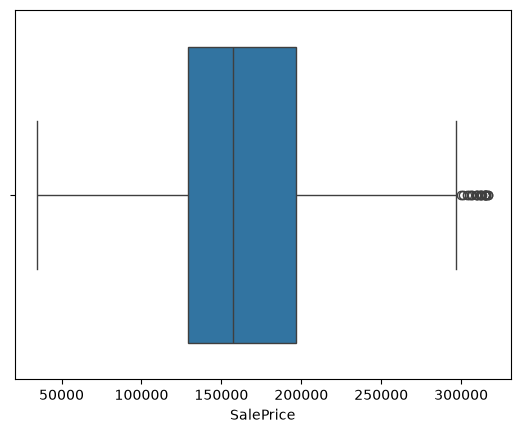

In [37]:
sns.boxplot(x = home['SalePrice'])

The box plot above shows that the saleprice column is more clean due to removal of outliers

## 4. Feature Engineering

New features that capture combined/derived information the raw columns don't
express on their own.

In [38]:
home['house_age'] = home['YrSold'] - home['YearBuilt']
home['total_sqft'] = home['TotalBsmtSF'] + home['1stFlrSF'] + home['2ndFlrSF']
home['area_per_room'] = home['GrLivArea'] / (home['TotRmsAbvGrd'] + 1)
home['garage_area_ratio'] = home['GarageArea'] / (home['GrLivArea'] + 1)
home['overall_space'] = home['GrLivArea'] + home['GarageArea']

Feature engineering was performed inorder for the model to find new patterns when learning

## 5. Target Transformation

Log transform was performed on Sale price inorder for the values to be distributed evenly so that the model wont focus or treat some with more importance than the other 

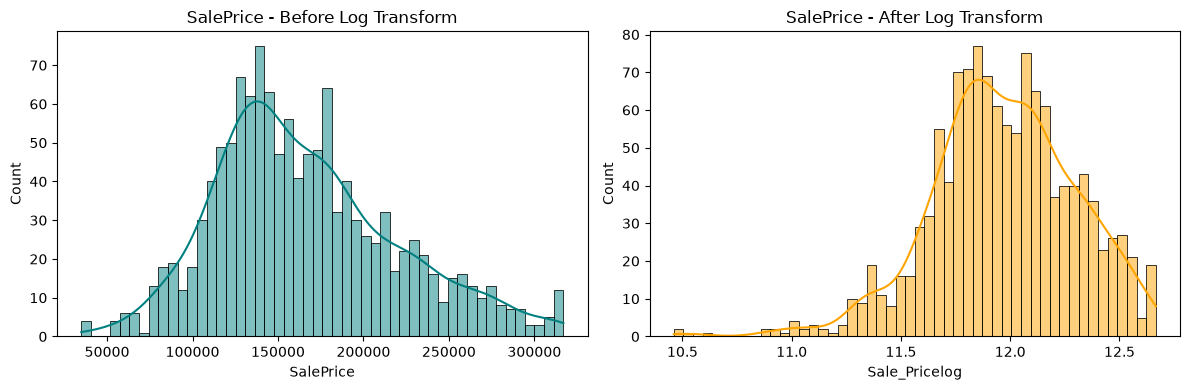

In [47]:
home['Sale_Pricelog'] = np.log1p(home['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(home['SalePrice'], bins=50, color='teal', edgecolor='black',ax = axes[0], kde = True)
axes[0].set_title('SalePrice - Before Log Transform')
sns.histplot(home['Sale_Pricelog'], bins=50, color='orange', edgecolor='black',kde = True, ax = axes[1])
axes[1].set_title('SalePrice - After Log Transform')
plt.tight_layout()
plt.show()

The subplots above shows the before and after log transform of saleprice. The Sale price before the log transform was right skewed and the Sale price after the log transform is more evenly distributed.

## 6. Exploratory Data Analysis

In [ ]:
numeric_cols = home_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

plt.figure(figsize=(14, 10))
corr = home_clean[numeric_cols].corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index
sns.heatmap(home_clean[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top Features vs SalePrice')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=home_clean, alpha=0.6, color='teal')
plt.title('GrLivArea vs SalePrice')
plt.show()

## 7. Encoding & Scaling

One-hot encode categorical columns, then scale all features with MinMaxScaler.

In [ ]:
cat_cols = home_clean.select_dtypes(include='object').columns.tolist()
train_encoded = pd.get_dummies(home_clean, columns=cat_cols, drop_first=True)

x = train_encoded.drop(columns=['SalePrice', 'Sale_Pricelog']).reset_index(drop=True)
y = train_encoded['Sale_Pricelog'].reset_index(drop=True)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

## 8. Recursive Feature Elimination (RFE)

Select the top 15 features to keep the model focused and reduce noise from
the large number of one-hot encoded columns.

In [ ]:
rfe = RFE(LinearRegression(), n_features_to_select=15)
rfe.fit(x_scaled, y)

selected_features = x_scaled.columns[rfe.support_]
print("Selected features:", list(selected_features))

x_rfe = x_scaled[selected_features]

## 9. Train/Test Split and Baseline Model Comparison

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_rfe, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(random_state=23),
    'XGBoost': XGBRegressor(random_state=23)
}

y_test_actual = np.expm1(y_test)
results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    log_preds = model.predict(x_test)
    actual_preds = np.expm1(log_preds)

    r2 = r2_score(y_test_actual, actual_preds)
    mse = mean_squared_error(y_test_actual, actual_preds)
    rmse = np.sqrt(mse)

    results.append({'Model': name, 'R2': round(r2, 4), 'MSE': round(mse, 2), 'RMSE': round(rmse, 2)})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
display(results_df)

## 10. Hyperparameter Tuning

Only the top performers get tuned. Ridge (or the best linear model) uses
GridSearchCV since its search space is small; the best tree-based model uses
RandomizedSearchCV since its search space is much larger.

In [ ]:
# --- Ridge Tuning (GridSearchCV) ---
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(x_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best Ridge CV R2:", round(ridge_grid.best_score_, 4))

In [ ]:
# --- XGBoost Tuning (RandomizedSearchCV) ---
xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0]
}
xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=23), xgb_params, n_iter=50, cv=5,
    scoring='r2', random_state=23, n_jobs=-1
)
xgb_random.fit(x_train, y_train)

print("Best XGBoost params:", xgb_random.best_params_)
print("Best XGBoost CV R2:", round(xgb_random.best_score_, 4))

## 11. Evaluate Tuned Models on the Test Set

In [ ]:
tuned_models = {
    'Ridge (tuned)': ridge_grid.best_estimator_,
    'XGBoost (tuned)': xgb_random.best_estimator_
}

for name, model in tuned_models.items():
    log_preds = model.predict(x_test)
    actual_preds = np.expm1(log_preds)
    r2 = r2_score(y_test_actual, actual_preds)
    rmse = np.sqrt(mean_squared_error(y_test_actual, actual_preds))
    print(f"{name}: R2={r2:.4f}, RMSE=${rmse:,.2f}")

## 12. Diagnostics — Actual vs Predicted, Residuals, Feature Importance

Using the tuned Ridge model as the final model (update this if XGBoost ends
up winning on your re-run).

In [ ]:
final_model = ridge_grid.best_estimator_

log_preds = final_model.predict(x_test)
actual_preds = np.expm1(log_preds)
actual_y = np.expm1(y_test)

plt.figure(figsize=(8, 6))
plt.scatter(actual_y, actual_preds, alpha=0.6, color='teal')
plt.plot([actual_y.min(), actual_y.max()], [actual_y.min(), actual_y.max()], 'r--', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices - Tuned Ridge')
plt.tight_layout()
plt.show()

In [ ]:
residuals = actual_y - actual_preds

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Residual Distribution - Tuned Ridge')
plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():,.2f}")
print(f"Std of residuals: ${residuals.std():,.2f}")

In [ ]:
coefficients = pd.Series(final_model.coef_, index=x_train.columns)
top_features = coefficients.sort_values(key=abs, ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='teal', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Feature Coefficients (Tuned Ridge)')
plt.tight_layout()
plt.show()

## 13. Save the Model

In [ ]:
joblib.dump(final_model, 'ridge_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(x_rfe.columns), 'feature_names.pkl')            # RFE-selected features the model uses
joblib.dump(x_scaled.columns.tolist(), 'all_feature_names.pkl')  # full pre-RFE feature list the scaler expects
joblib.dump(x_scaled.median(), 'feature_medians.pkl')            # medians to fill features not exposed to the user

print("Model, scaler, feature names and medians saved successfully.")

## 14. Conclusion

This project built an end-to-end machine learning pipeline to predict house
prices. After data cleaning, feature engineering, and exploratory analysis,
five models were compared, and the top performer(s) were tuned with
GridSearchCV / RandomizedSearchCV.

Key findings:
- Overall quality and condition are the strongest drivers of price.
- House age negatively affects price — older houses are worth less.
- Engineered features (`total_sqft`, `house_age`) ranked among the most
  important predictors, confirming the feature engineering added real value.
- Log-transforming the target improved model behavior and produced residuals
  centered near zero with no major systematic bias.

The final tuned model and its supporting artifacts (scaler, feature list,
medians) were saved for use in a deployed prediction API.